In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error

df=pd.read_csv('Advertising.csv',index_col=0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [14]:
df.info()
print(df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


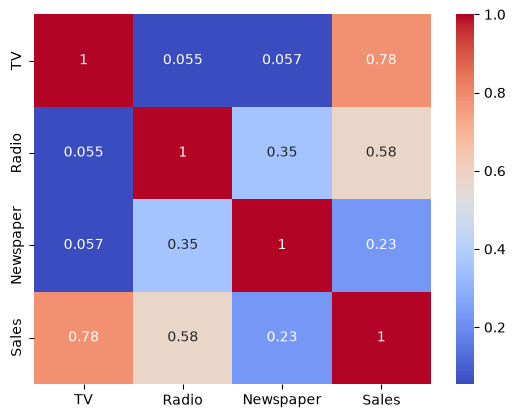

In [15]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

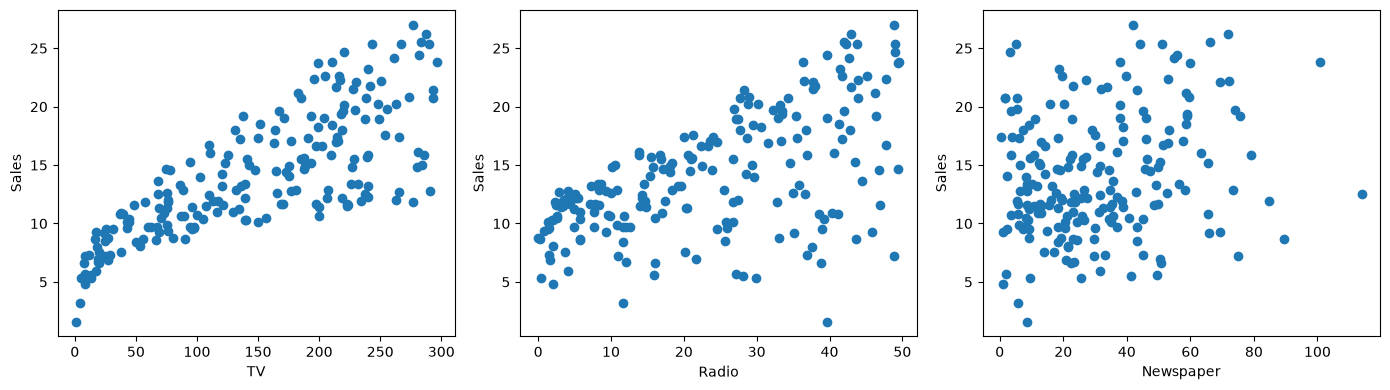

In [16]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].scatter(df['TV'],df['Sales'])
axes[0].set_xlabel('TV')
axes[0].set_ylabel('Sales')
axes[1].scatter(df['Radio'],df['Sales'])
axes[1].set_xlabel('Radio')
axes[1].set_ylabel('Sales')
axes[2].scatter(df['Newspaper'],df['Sales'])
axes[2].set_xlabel('Newspaper')
axes[2].set_ylabel('Sales')
plt.tight_layout()
plt.show()

In [17]:
X=df[['TV','Radio','Newspaper']]
y=df['Sales']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print('Linear Regression')
print('R2:',r2_score(y_test,lr_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,lr_pred)))

Linear Regression
R2: 0.899438024100912
RMSE: 1.78159966153345


In [19]:
ridge=Ridge()
ridge.fit(X_train,y_train)
ridge_pred=ridge.predict(X_test)
print('Ridge Regression')
print('R2:',r2_score(y_test,ridge_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,ridge_pred)))

Ridge Regression
R2: 0.89943810463304
RMSE: 1.781598948162221


In [20]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print('Random Forest')
print('R2:',r2_score(y_test,rf_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,rf_pred)))

Random Forest
R2: 0.9812782416450916
RMSE: 0.7687170968568338


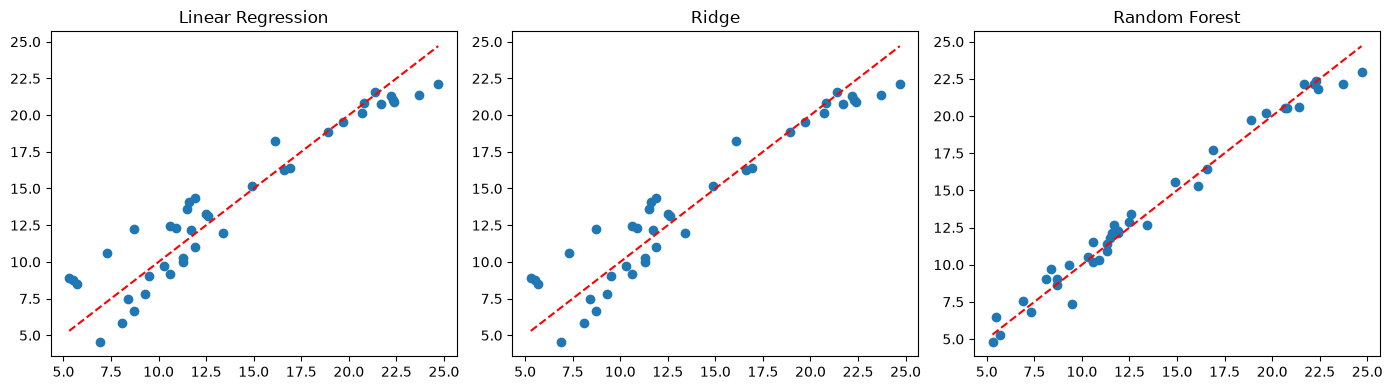

In [21]:
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].scatter(y_test,lr_pred)
axes[0].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
axes[0].set_title('Linear Regression')
axes[1].scatter(y_test,ridge_pred)
axes[1].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
axes[1].set_title('Ridge')
axes[2].scatter(y_test,rf_pred)
axes[2].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
axes[2].set_title('Random Forest')
plt.tight_layout()
plt.show()

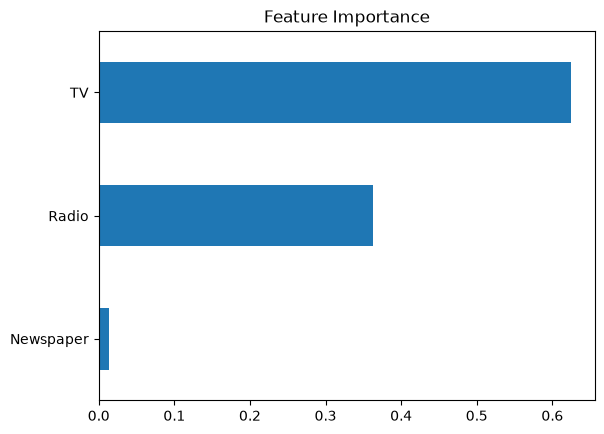

In [22]:
feat_imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values()
feat_imp.plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [23]:
new_data=pd.DataFrame([[200,40,30]],columns=['TV','Radio','Newspaper'])
prediction=rf.predict(new_data)
print('TV=200, Radio=40, Newspaper=30')
print('Predicted Sales:',round(prediction[0],2),'(x1000 units)')

TV=200, Radio=40, Newspaper=30
Predicted Sales: 20.29 (x1000 units)
